# Brazilian E-Commerce Sales Analysis

This project analyses Brazilian e-commerce transaction data to identify revenue drivers, customer behaviour and growth opportunities.

The analysis explores:

- Revenue distribution across product categories
- Geographic revenue concentration
- Customer revenue distribution
- Order price behaviour
- Seasonal sales patterns

The goal is to generate insights that could help an e-commerce retailer improve marketing strategy, pricing decisions and product focus.

## Dataset

The dataset contains **112,650 transactions** from a Brazilian e-commerce platform.

Variables used in this analysis include:

- `order_date` – date of purchase  
- `price` – order item price  
- `product_category_name` – product category  
- `customer_city` – customer location  
- `customer_id` – unique customer identifier  

The dataset represents **~96,000 unique customers across more than 4,000 cities**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:

df = pd.read_csv(r"C:\Users\Lenovo\Data_Analysis_Business\Project6\analysis_table.csv")

df.head()

,order_date,price,product_category_name,customer_city,customer_id
0,2017-09-13,58.90,cool_stuff,campos dos goytacazes,871766c5855e863f6eccc05f988b23cb
1,2017-04-26,239.90,pet_shop,santa fe do sul,eb28e67c4c0b83846050ddfb8a35d051
2,2018-01-14,199.00,moveis_decoracao,para de minas,3818d81c6709e39d06b2738a8d3a2474
3,2018-08-08,12.99,perfumaria,atibaia,af861d436cfc08b2c2ddefd0ba074622
4,2017-02-04,199.90,ferramentas_jardim,varzea paulista,64b576fb70d441e8f1b2d7d446e483c5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_date             112650 non-null  object 
 1   price                  112650 non-null  float64
 2   product_category_name  111047 non-null  object 
 3   customer_city          112650 non-null  object 
 4   customer_id            112650 non-null  object 
dtypes: float64(1), object(4)
memory usage: 4.3+ MB


In [4]:
df.describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [6]:
df.head()

,order_date,price,product_category_name,customer_city,customer_id
0,2017-09-13,58.90,cool_stuff,campos dos goytacazes,871766c5855e863f6eccc05f988b23cb
1,2017-04-26,239.90,pet_shop,santa fe do sul,eb28e67c4c0b83846050ddfb8a35d051
2,2018-01-14,199.00,moveis_decoracao,para de minas,3818d81c6709e39d06b2738a8d3a2474
3,2018-08-08,12.99,perfumaria,atibaia,af861d436cfc08b2c2ddefd0ba074622
4,2017-02-04,199.90,ferramentas_jardim,varzea paulista,64b576fb70d441e8f1b2d7d446e483c5


## Top product category revenue analysis

In [7]:
category_revenue = df.groupby("product_category_name")["price"].sum().sort_values(ascending=False)

category_revenue.head(10)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64

In [8]:
plt.style.use("seaborn-v0_8")

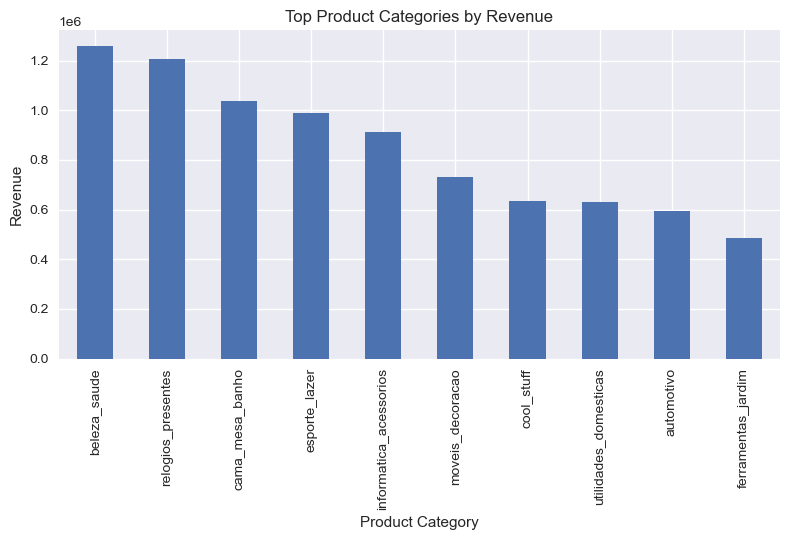

In [9]:
import matplotlib.pyplot as plt

category_revenue.head(10).plot(kind="bar")

plt.title("Top Product Categories by Revenue")
plt.ylabel("Revenue")
plt.xlabel("Product Category")

plt.tight_layout()
plt.show()

## Monthly revenue trend analysis

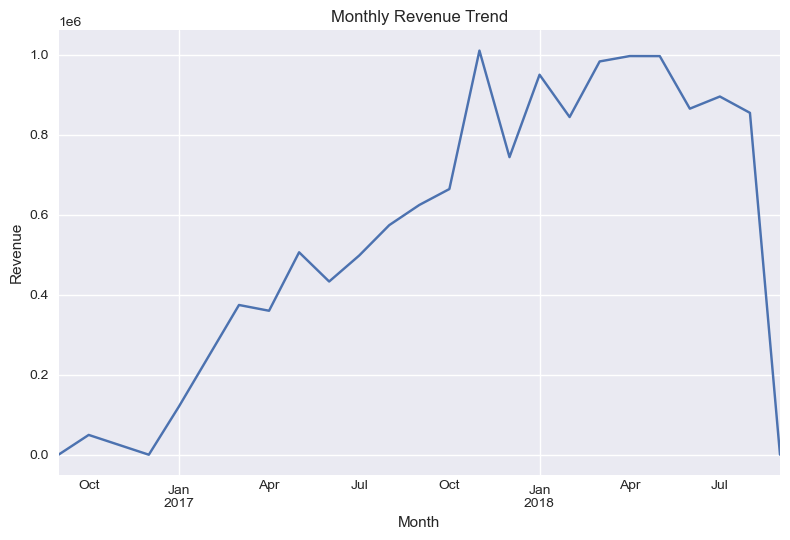

In [10]:
monthly_revenue = df.groupby(df["order_date"].dt.to_period("M"))["price"].sum()

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

In [11]:
df["order_date"].max()

Timestamp('2018-09-03 00:00:00')

## City revenue analysis

In [12]:
city_revenue = df.groupby("customer_city")["price"].sum().sort_values(ascending=False)

city_revenue.head(10)

customer_city
sao paulo         1914924.54
rio de janeiro     992538.86
belo horizonte     355611.13
brasilia           301920.25
curitiba           211738.06
porto alegre       190562.08
campinas           187844.53
salvador           181104.42
guarulhos          144268.39
niteroi            117907.12
Name: price, dtype: float64

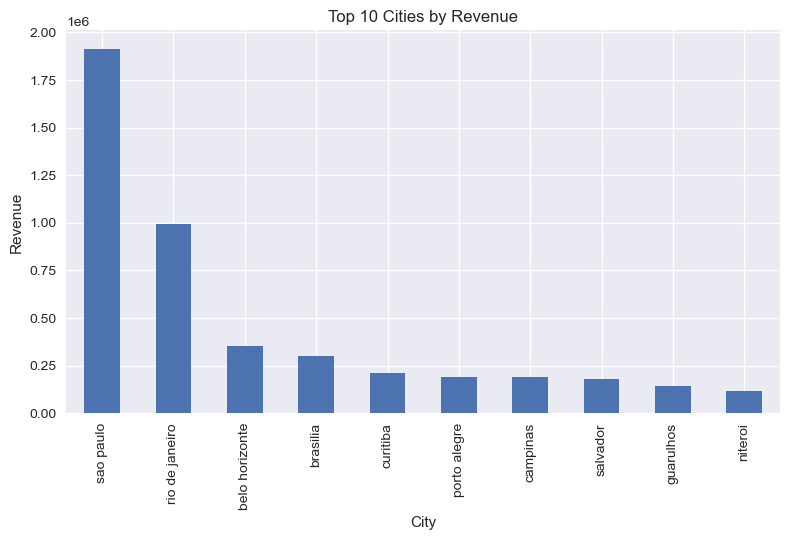

In [13]:
city_revenue.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Revenue")
plt.ylabel("Revenue")
plt.xlabel("City")

plt.tight_layout()
plt.show()

## Top products monthly revenue trend analysis

In [14]:
category_monthly = df.groupby(
    [df["order_date"].dt.to_period("M"), "product_category_name"]
)["price"].sum().unstack()

category_monthly.head()

product_category_name,agro_industria_e_comercio,alimentos,alimentos_bebidas,artes,artes_e_artesanato,artigos_de_festas,artigos_de_natal,audio,automotivo,bebes,...,pet_shop,portateis_casa_forno_e_cafe,portateis_cozinha_e_preparadores_de_alimentos,relogios_presentes,seguros_e_servicos,sinalizacao_e_seguranca,tablets_impressao_imagem,telefonia,telefonia_fixa,utilidades_domesticas
order_date,,,,,,,,,,,,,,,,,,,,,
2016-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.50,NaN,NaN
2016-10,NaN,79.90,NaN,NaN,NaN,NaN,NaN,156.99,1833.25,1630.16,...,689.68,NaN,NaN,3360.24,NaN,NaN,NaN,500.08,704.88,1287.07
2016-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,65.97,42.82,NaN,NaN,NaN,NaN,NaN,NaN,5218.53,6397.87,...,967.12,NaN,NaN,8086.52,183.29,NaN,NaN,2945.86,677.12,2827.58
2017-02,224.84,715.63,NaN,NaN,NaN,NaN,NaN,163.80,13162.40,3048.48,...,3729.07,NaN,NaN,11756.21,NaN,NaN,792.0,6899.09,759.23,12659.67


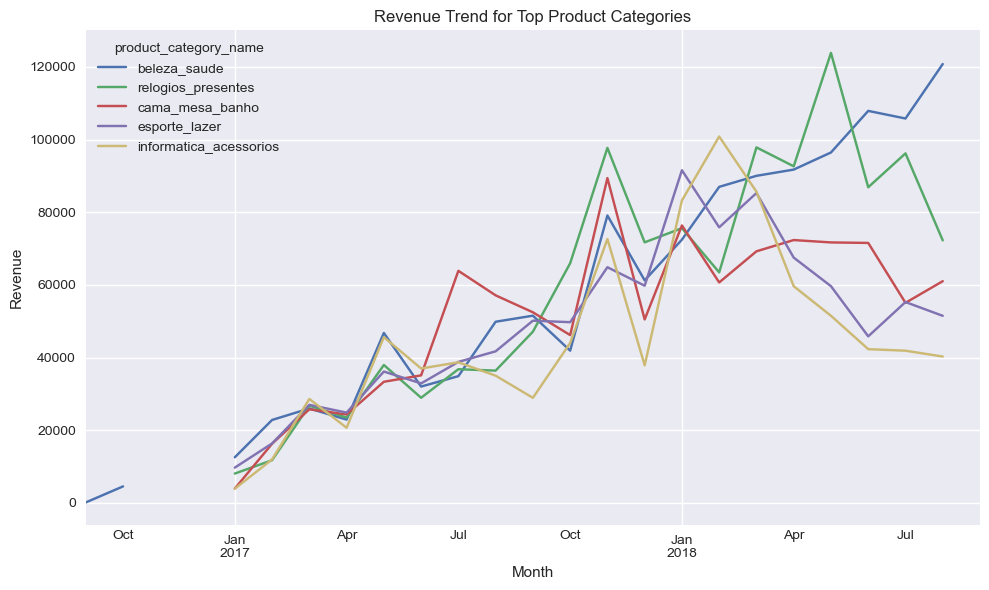

In [15]:
top_categories = category_revenue.head(5).index

category_monthly[top_categories].plot(figsize=(10,6))

plt.title("Revenue Trend for Top Product Categories")
plt.ylabel("Revenue")
plt.xlabel("Month")

plt.tight_layout()
plt.show()

## Order price distribution analysis

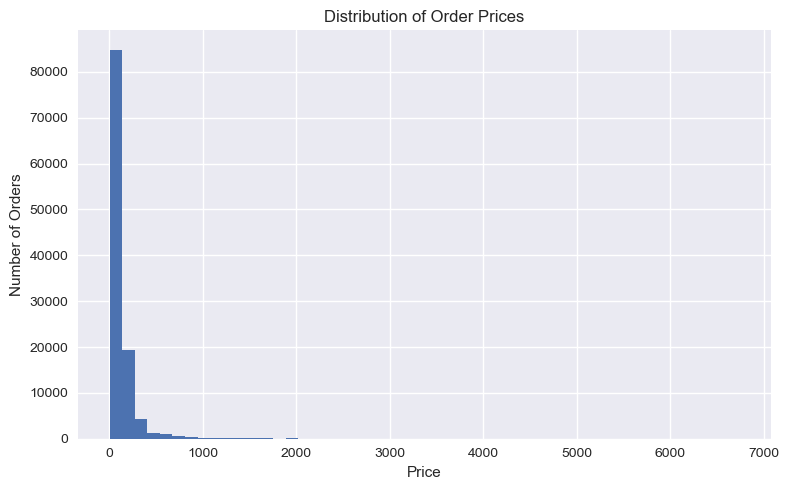

In [16]:
plt.figure(figsize=(8,5))

df["price"].hist(bins=50)

plt.title("Distribution of Order Prices")
plt.xlabel("Price")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

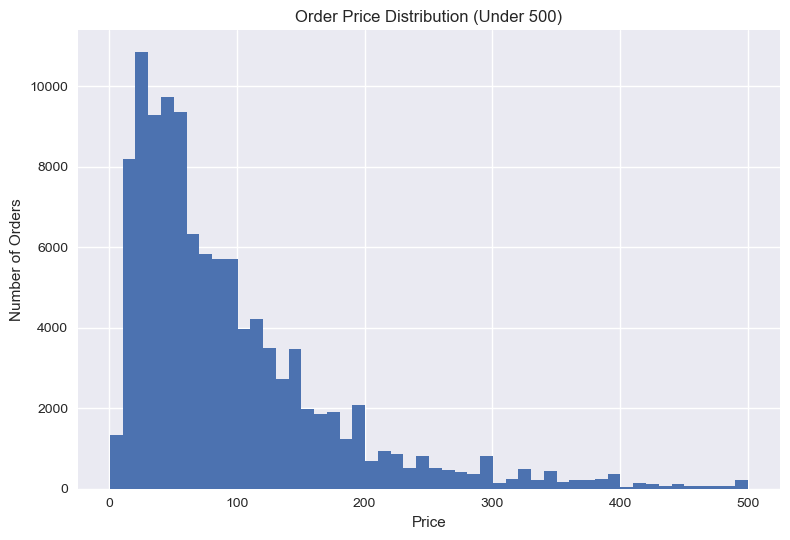

In [17]:
df[df["price"] < 500]["price"].hist(bins=50)

plt.title("Order Price Distribution (Under 500)")
plt.xlabel("Price")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Price by category analysis

In [18]:
avg_price_category = df.groupby("product_category_name")["price"].mean().sort_values(ascending=False)

avg_price_category.head(10)

product_category_name
pcs                                              1098.340542
portateis_casa_forno_e_cafe                       624.285658
eletrodomesticos_2                                476.124958
agro_industria_e_comercio                         342.124858
instrumentos_musicais                             281.616000
eletroportateis                                   280.778468
portateis_cozinha_e_preparadores_de_alimentos     264.568667
telefonia_fixa                                    225.693182
construcao_ferramentas_seguranca                  208.992371
relogios_presentes                                201.135984
Name: price, dtype: float64

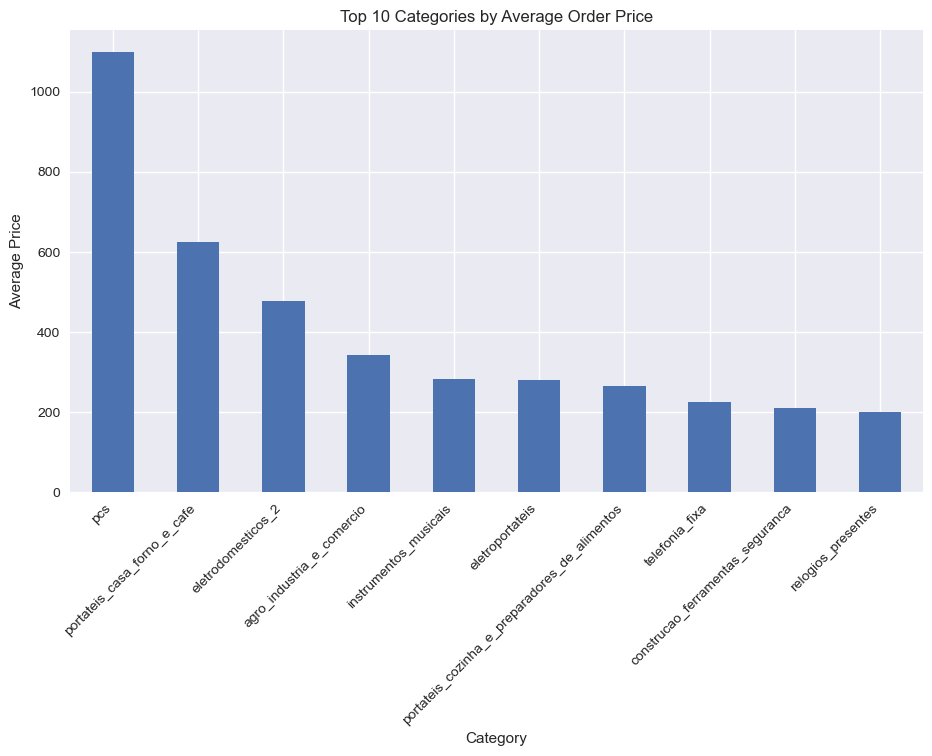

In [19]:
avg_price_category.sort_values(ascending=False).head(10).plot(kind="bar", figsize=(11,6))

plt.title("Top 10 Categories by Average Order Price")
plt.ylabel("Average Price")
plt.xlabel("Category")

plt.xticks(rotation=45, ha="right")

plt.show()

## Price band analysis

In [20]:
bins = [0,50,100,200,500,1000,7000]
labels = ["0-50","50-100","100-200","200-500","500-1000","1000+"]

df["price_band"] = pd.cut(df["price"], bins=bins, labels=labels)

In [21]:
price_band_counts = df["price_band"].value_counts().sort_index()

price_band_counts

price_band
0-50        39317
50-100      33020
100-200     26939
200-500     10158
500-1000     2372
1000+         844
Name: count, dtype: int64

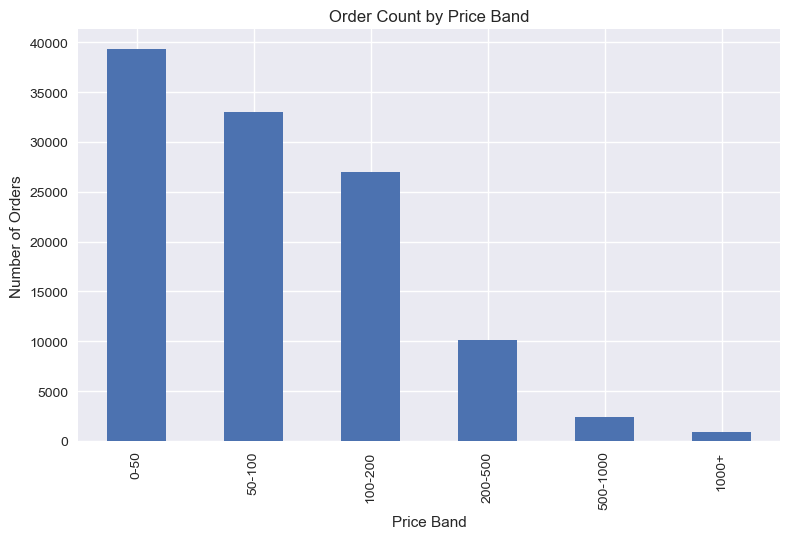

In [22]:
price_band_counts.plot(kind="bar")

plt.title("Order Count by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Pareto analysis by city section

In [23]:
city_revenue = df.groupby("customer_city")["price"].sum().sort_values(ascending=False)

city_revenue.head(10)

customer_city
sao paulo         1914924.54
rio de janeiro     992538.86
belo horizonte     355611.13
brasilia           301920.25
curitiba           211738.06
porto alegre       190562.08
campinas           187844.53
salvador           181104.42
guarulhos          144268.39
niteroi            117907.12
Name: price, dtype: float64

In [24]:
city_revenue_df = city_revenue.reset_index()
city_revenue_df.columns = ["city", "revenue"]

city_revenue_df["cumulative_revenue"] = city_revenue_df["revenue"].cumsum()
city_revenue_df["cumulative_percent"] = 100 * city_revenue_df["cumulative_revenue"] / city_revenue_df["revenue"].sum()

city_revenue_df.head(10)

,city,revenue,cumulative_revenue,cumulative_percent
0,sao paulo,1914924.54,1914924.54,14.088984
1,rio de janeiro,992538.86,2907463.40,21.391551
2,belo horizonte,355611.13,3263074.53,24.007946
3,brasilia,301920.25,3564994.78,26.229313
4,curitiba,211738.06,3776732.84,27.787168
5,porto alegre,190562.08,3967294.92,29.189221
6,campinas,187844.53,4155139.45,30.571280
7,salvador,181104.42,4336243.87,31.903749
8,guarulhos,144268.39,4480512.26,32.965198
9,niteroi,117907.12,4598419.38,33.832695


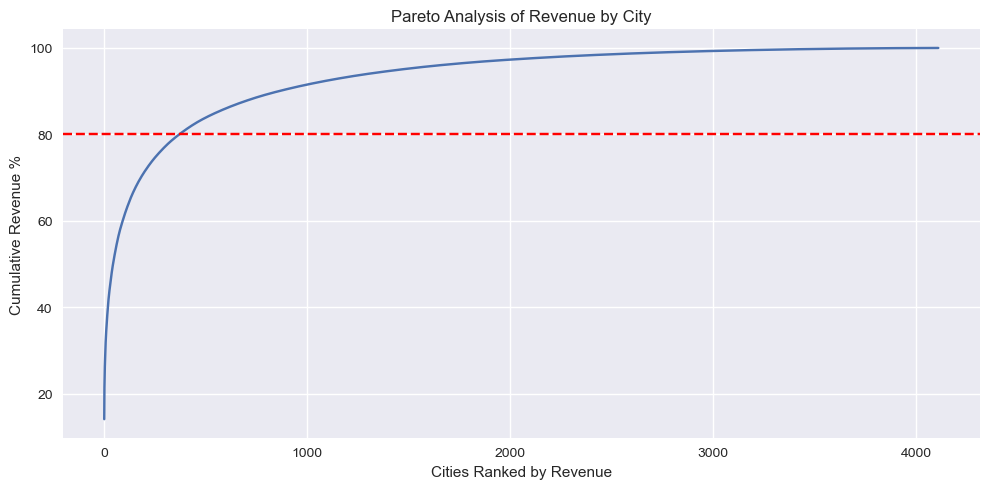

In [25]:
plt.figure(figsize=(10,5))

plt.plot(city_revenue_df["cumulative_percent"])

plt.axhline(80, color="red", linestyle="--")

plt.title("Pareto Analysis of Revenue by City")
plt.xlabel("Cities Ranked by Revenue")
plt.ylabel("Cumulative Revenue %")

plt.tight_layout()
plt.show()

check the exact number of cities in the dataset

In [26]:
df["customer_city"].nunique()

4110

check how much revenue % the top 10 cities account for

In [27]:
top10_share = city_revenue.head(10).sum() / city_revenue.sum()
top10_share

np.float64(0.3383269515812866)

check how what % of revenue comes from Sao Paulo (the biggest revenue city in the data set)

In [28]:
city_revenue["sao paulo"] / city_revenue.sum()

np.float64(0.14088984248461428)

## Revenue Heatmap by Category and Month

In [29]:
heatmap_data = df.groupby(
    [df["order_date"].dt.to_period("M"), "product_category_name"]
)["price"].sum().unstack()

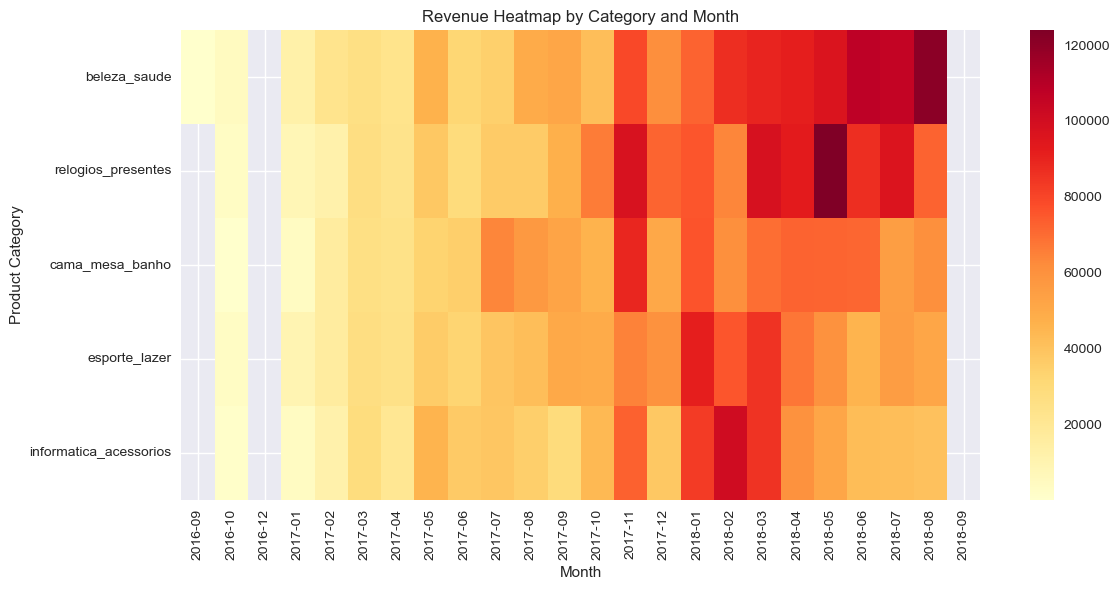

In [30]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data[top_categories].T,
    cmap="YlOrRd"
)

plt.title("Revenue Heatmap by Category and Month")
plt.xlabel("Month")
plt.ylabel("Product Category")

plt.tight_layout()

plt.show()

## Customer revenue concentration analysis

In [31]:
customer_revenue = df.groupby("customer_id")["price"].sum().sort_values(ascending=False)
customer_revenue.head()

customer_id
0a0a92112bd4c708ca5fde585afaa872    13440.0
da122df9eeddfedc1dc1f5349a1a690c     7388.0
763c8b1c9c68a0229c42c9fc6f662b93     7160.0
dc4802a71eae9be1dd28f5d788ceb526     6735.0
459bef486812aa25204be022145caa62     6729.0
Name: price, dtype: float64

In [32]:
customer_cumulative = customer_revenue.cumsum() / customer_revenue.sum() * 100

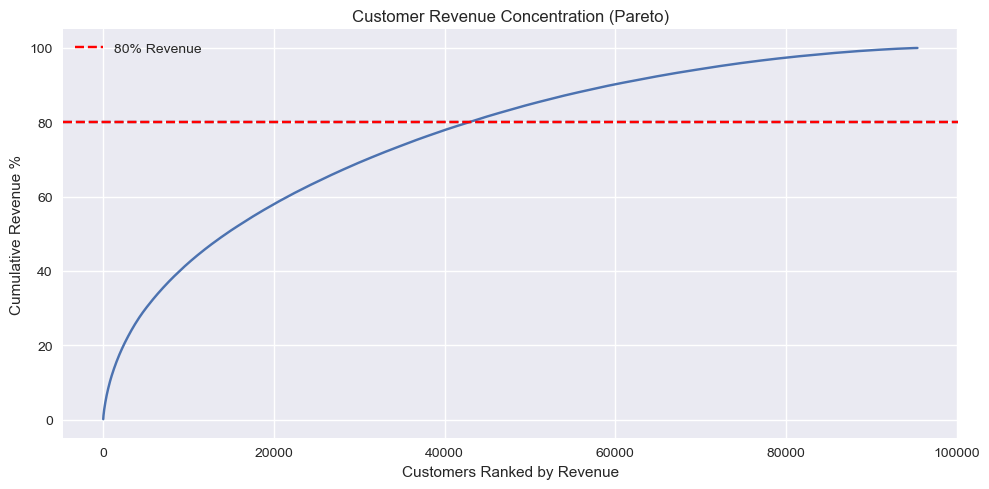

In [33]:
plt.figure(figsize=(10,5))

plt.plot(customer_cumulative.values)
plt.axhline(80, linestyle="--")

plt.title("Customer Revenue Concentration (Pareto)")
plt.xlabel("Customers Ranked by Revenue")
plt.ylabel("Cumulative Revenue %")

plt.axhline(80, linestyle="--", color="red", label="80% Revenue")
plt.legend()

plt.tight_layout()
plt.show()

show total number of customers in data set

In [34]:
print("Number of unique customers:", df["customer_id"].nunique())

Number of unique customers: 95420


show total number of orders

In [35]:
len(df)

112650

## Key Business Insights

Revenue Concentration

Revenue is strongly concentrated in Brazil’s largest metropolitan areas, with São Paulo and Rio de Janeiro generating a disproportionately large share of total revenue, indicating that the company’s core customer base is concentrated in Brazil’s largest metropolitan areas. This suggests that logistics infrastructure, warehouse placement and marketing investment should prioritise these locations.

Product Pricing Behaviour

Most orders fall within the £20–£100 price range, with demand declining sharply above £200. This indicates that the business primarily operates in the low-to-mid price segment, with high-priced items contributing relatively few transactions.

Category Growth Trends

The Beleza (Beauty & Health) category demonstrates the strongest long-term growth across the dataset. Revenue steadily increases toward the end of the observation period, suggesting growing demand and potential for further expansion in this category.

Seasonal Demand Patterns

Sales peaks appear during January–March, likely reflecting increased consumer spending during Brazil’s summer holiday season. Additionally, a spike in May within the watches/gifts category may be linked to Mother’s Day, an important retail event in Brazil.

Customer Revenue Distribution

Revenue is moderately distributed across the customer base. Approximately 40% of customers account for 80% of total revenue, indicating that the business is not heavily dependent on a small number of high-spending customers. This suggests a broad consumer base, typical of e-commerce retailers operating in the mass market segment.

Strategic Implications

The business could increase performance by:

expanding inventory in high-growth categories such as beauty products

prioritising marketing spend in high-revenue cities

running targeted campaigns around key retail events such as Mother’s Day

focusing pricing strategy around the £20–£100 range where most transactions occur

## Business Recommendations

Based on the analysis, several strategic opportunities emerge.

1. Focus on High-Revenue Cities

Sales are highly concentrated in major metropolitan areas such as São Paulo and Rio de Janeiro. The company should prioritise these regions for marketing campaigns, warehouse placement, and delivery optimisation.

2. Expand High-Growth Product Categories

The Beauty & Health (Beleza) category demonstrates strong revenue growth across the dataset. Expanding product variety and marketing investment in this segment could drive further growth.

3. Optimise Pricing Strategy

Most orders fall within the £20–£100 range, suggesting that customers are most responsive within this price band. Product assortment and promotions should focus on this range to maximise conversion rates.

4. Target Key Seasonal Events

Sales patterns suggest demand spikes around Brazilian summer months and Mother’s Day (May). Marketing campaigns should be aligned with these events to maximise seasonal demand.

5. Maintain Product Diversity

Revenue is generated across a wide range of product categories and cities, suggesting the business benefits from maintaining a diverse product catalogue rather than relying on a single segment.

6. Focus on Customer Acquisition

Because revenue is distributed across a large number of customers rather than a small group of high spenders, business growth will likely come from expanding the customer base rather than relying on a small number of repeat buyers. Investment in digital marketing, product discovery and marketplace visibility could therefore generate meaningful revenue growth.

## Tools Used

SQL – data extraction and table joins  
Python (Pandas) – data cleaning and analysis  
Matplotlib / Seaborn – visualisation  
Jupyter Notebook – analysis environment